In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.polys.subresultants_qq_zz import final_touches

In [14]:
x=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_xor=np.array([[0],[1],[1],[0]])

In [15]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
def sigmoid_derivative(x):
    return x*(1-x)

In [16]:
class OneHiddenLayerNN:
    def __init__(self, hidden_size,lr=0.5,epoch=30000):
        self.hidden_size=hidden_size
        self.lr = lr
        self.epoch=epoch
        self.loss=[]

    def fit(self,x,y):


        self.W1=np.random.randn(2,self.hidden_size)*0.1
        self.b1=np.zeros((1,self.hidden_size))

        self.W2=np.random.randn(self.hidden_size,1)*0.1
        self.b2=np.zeros((1,1))

        for _ in range(self.epoch):
            z1=np.dot(x,self.W1)+self.b1
            a1=sigmoid(z1)

            z2=np.dot(a1,self.W2)+self.b2
            y_hat=sigmoid(z2)

            #loss=-np.mean((y_hat-y)**2)
            loss=-np.mean(y*np.log(y_hat+1e-8)+(1-y)*np.log(1-y_hat+1e-8))
            self.loss.append(loss)

            error_output=y-y_hat
            d_output=error_output*sigmoid_derivative(y_hat)

            error_hidden=np.dot(d_output,self.W2.T)
            d_hidden=error_hidden*sigmoid_derivative(a1)

            self.W2+=self.lr*np.dot(a1.T,d_output)
            self.b2+=self.lr*np.sum(d_output,axis=0,keepdims=True)

            self.W1+=self.lr*np.dot(x.T,d_hidden)
            self.b1+=self.lr*np.sum(d_hidden,axis=0,keepdims=True)

            #print("Raw output:", y_hat.T)
            #print("Loss:", loss)
        #self.final_loss = loss


    def predict(self,x):
        a1=sigmoid(np.dot(x,self.W1)+self.b1)
        y_hat=sigmoid(np.dot(a1,self.W2)+self.b2)
        return (y_hat>=0.5).astype(int)




In [17]:
#np.random.seed(42)
for h in [2,3,4]:
    model=OneHiddenLayerNN(hidden_size=h)
    model.fit(x,y_xor)
    predicts=model.predict(x)
    acc=np.mean(predicts==y_xor)
    print("Hidden layer",h,"Accuracy:",acc)
    #print(f"Final Loss: {model.final_loss:.4f}")


Hidden layer 2 Accuracy: 1.0
Hidden layer 3 Accuracy: 1.0
Hidden layer 4 Accuracy: 1.0


In [18]:
num_run=10
hidden_sizes=[2,3,4]
epoch=30000

result={}

for h in hidden_sizes:
    all_losses=[]
    all_accuracies=[]

    for run in range(num_run):
        np.random.seed(run)

        model=OneHiddenLayerNN(hidden_size=h,epoch=epoch)
        model.fit(x,y_xor)
        all_losses.append(model.loss)
        predictions=model.predict(x)
        acc=np.mean(predictions==y_xor)
        all_accuracies.append(acc)

    result[h]={
        'loss': np.array(all_losses),
        'accuracy': np.array(all_accuracies)
    }

for h in hidden_sizes:
    result[h]["Mean_loss"]=np.mean(result[h]["loss"],axis=0)
    result[h]["Std_loss"]=np.std(result[h]["loss"],axis=0)
    result[h]["Mean_accuracy"]=np.mean(result[h]["accuracy"])



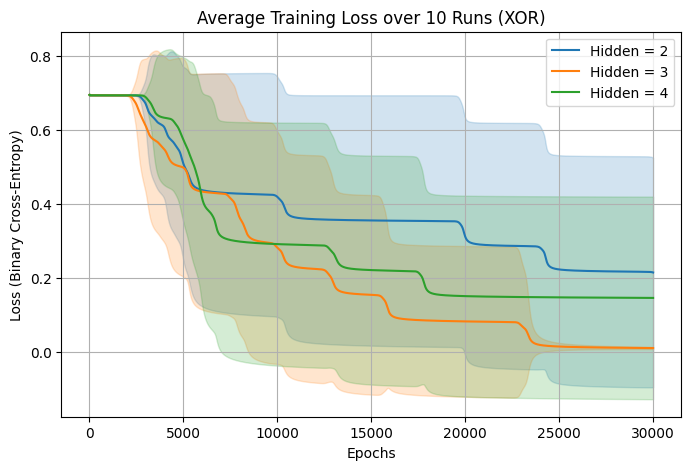

In [19]:


plt.figure(figsize=(8,5))

colors = {
    2: "tab:blue",
    3: "tab:orange",
    4: "tab:green"
}

for h in [2, 3, 4]:
    #model = OneHiddenLayerNN(hidden_size=h)

    mean_loss=result[h]["Mean_loss"]
    std_loss=result[h]["Std_loss"]

    plt.plot(mean_loss,
             color=colors[h],
             label=f"Hidden = {h}"
    )

    plt.fill_between(
        range(len(mean_loss)),
        mean_loss-std_loss,
        mean_loss+std_loss,
        color=colors[h],
        alpha=0.2
    )

plt.xlabel("Epochs")
plt.ylabel("Loss (Binary Cross-Entropy)")

plt.title("Average Training Loss over 10 Runs (XOR)")
plt.grid(True)
plt.legend()
plt.show()


In [20]:
for h in hidden_sizes:
    final_losses=result[h]["loss"][:,-1]
    print(f"Hidden = {h}")
    print(f"Mean Accuracy: {result[h]['Mean_accuracy']:.2f}")
    print(f"Final Loss: {np.mean(final_losses):.4f} ± {np.std(final_losses):.4f}")
    print()

Hidden = 2
Mean Accuracy: 0.88
Final Loss: 0.2153 ± 0.3092

Hidden = 3
Mean Accuracy: 1.00
Final Loss: 0.0115 ± 0.0030

Hidden = 4
Mean Accuracy: 0.90
Final Loss: 0.1467 ± 0.2732

